==================PROSES PEMUATAN DATASET==================

[1/3] Memuat dataset_final\train
Found 865 files belonging to 4 classes.



[2/3] Memuat dataset_final\val
Found 136 files belonging to 4 classes.

[3/3] Memuat dataset_final\test
Found 137 files belonging to 4 classes.

==================INFORMASI KELAS & MAPPING==================
Kelas ditemukan: ['1', '2', '3', '4']

Index Model     | Nama Folder     | Nilai PPB (Target)  
------------------------------------------------------------
0               | 1               | 1                        
1               | 2               | 2                        
2               | 3               | 3                        
3               | 4               | 4                        

Selesai. Dataset siap digunakan.
Step 2: Setting up data augmentation...
✓ RandomFlip (horizontal)
✓ RandomRotation (±10°)
Menerapkan preprocessing ke dataset...
✓ Training dataset: augmentation ON, cache ON, prefetch ON
✓ Validation dataset: augmentation OFF, cache ON, prefetch ON
✓ Test dataset: augmentation OFF, cache ON, prefetch ON

PREPROCESSING SELESAI

Dataset siap digunakan 

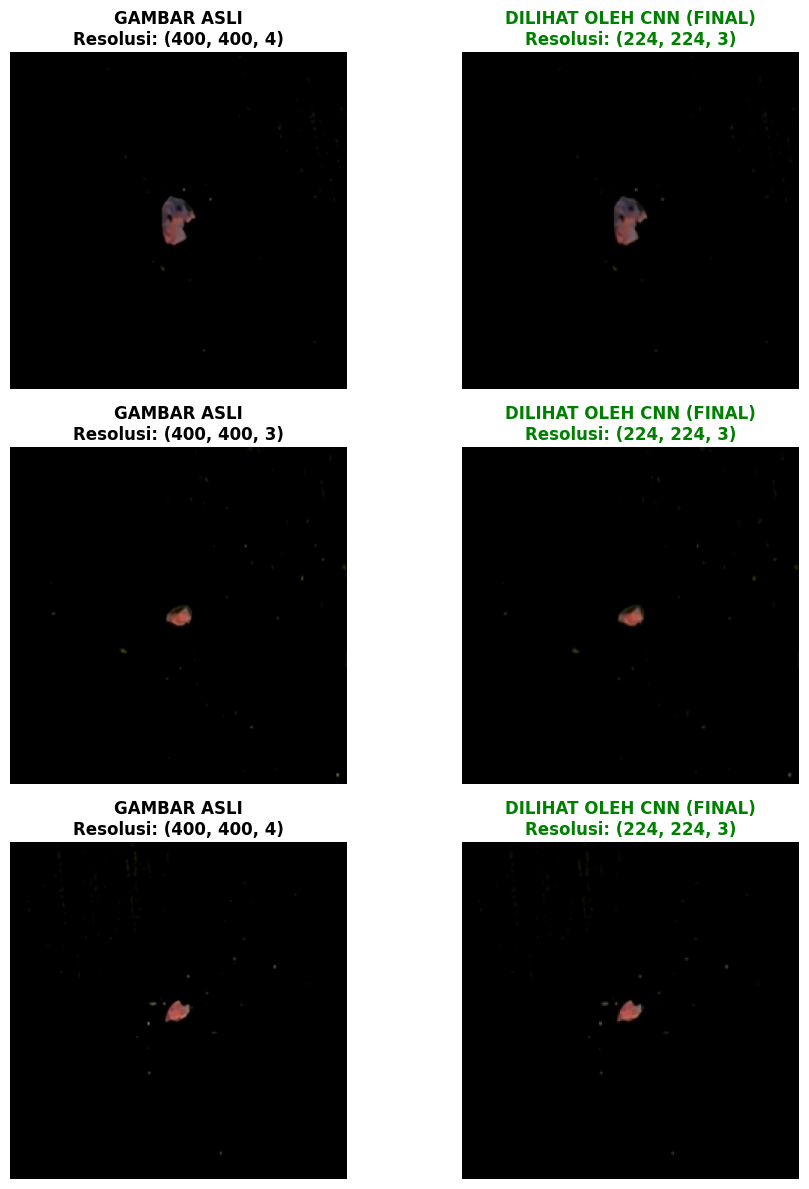


[INFO] Libraries berhasil dimuat!
[INFO] Dataset siap digunakan untuk Custom CNN.


In [11]:
# =================================================================================================
# 1. IMPORT LIBRARIES & LOAD PREPROCESSED DATA
# =================================================================================================
# Pastikan file preprocess.ipynb sudah diubah (Normalisasi /255.0 dan label_mode="categorical")
%run PreprocessCustom.ipynb 

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import AdamW, SGD, RMSprop, Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("\n[INFO] Libraries berhasil dimuat!")
print("[INFO] Dataset siap digunakan untuk Custom CNN.")

In [12]:
# =================================================================================================
# 2. PERHITUNGAN CLASS WEIGHTS
# =================================================================================================
# Menangani ketidakseimbangan data (128, 256, 161, 63)
# Memberikan "denda" lebih besar jika model salah menebak Kelas 4

jumlah_kelas = {
    0: 200,  # Kelas 1 
    1: 265,  # Kelas 2 
    2: 200,  # Kelas 3 
    3: 200   # Kelas 4
}
total_data = sum(jumlah_kelas.values())
num_classes = len(jumlah_kelas)

class_weights = {}
for cls, count in jumlah_kelas.items():
    # Rumus standar industri: w = total / (jumlah_kelas * sampel_kelas)
    class_weights[cls] = total_data / (num_classes * count)

print("="*60)
print("⚖️ BOBOT KELAS (CLASS WEIGHTS)")
print("="*60)
for cls, weight in class_weights.items():
    print(f"Kelas {cls+1} PPB : Bobot {weight:.4f}")
print("Semakin tinggi bobot, semakin model dipaksa memperhatikan kelas tersebut.")

⚖️ BOBOT KELAS (CLASS WEIGHTS)
Kelas 1 PPB : Bobot 1.0813
Kelas 2 PPB : Bobot 0.8160
Kelas 3 PPB : Bobot 1.0813
Kelas 4 PPB : Bobot 1.0813
Semakin tinggi bobot, semakin model dipaksa memperhatikan kelas tersebut.


In [13]:
# =================================================================================================
# 3. MEMBANGUN ARSITEKTUR CUSTOM CNN (FOKUS PENDARAN UV)
# =================================================================================================

def build_aflatoxin_uv_cnn():
    inputs = tf.keras.Input(shape=(224, 224, 3), name="Input_Layer")
    
    # --- BLOK 1: Deteksi Kontras & Tepi Dasar ---
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same', name="Conv1")(inputs)
    x = layers.MaxPooling2D((2, 2), name="Pool1")(x)
    
    # --- BLOK 2: Ekstraksi Pola Pendaran ---
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name="Conv2")(x)
    x = layers.MaxPooling2D((2, 2), name="Pool2")(x)
    
    # --- BLOK 3: Fitur Menengah ---
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name="Conv3")(x)
    x = layers.MaxPooling2D((2, 2), name="Pool3")(x)
    
    # --- BLOK 4: Fitur Tingkat Lanjut ---
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name="Conv4")(x)
    x = layers.MaxPooling2D((2, 2), name="Pool4")(x)
    
    # ========================================================================
    # 🌟 INOVASI DUAL-POOLING (SANGAT PENTING UNTUK SKRIPSI) 🌟
    # ========================================================================
    # 1. Mencari Intensitas Tertinggi (Titik Paling Terang)
    max_pool = layers.GlobalMaxPooling2D(name="Peak_Brightness_Detector")(x)
    
    # 2. Mencari Luas Area Rata-rata Pendaran
    avg_pool = layers.GlobalAveragePooling2D(name="Spatial_Extent_Detector")(x)
    
    # Gabungkan kedua informasi fisik tersebut
    merged = layers.Concatenate(name="Feature_Fusion")([max_pool, avg_pool])
    # ========================================================================
    
    # --- KEPALA KLASIFIKASI (Dense Network) ---
    # Gunakan L2 Regularization untuk "mengerem" model agar tidak cepat overfit
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01), name="Dense_Hidden")(merged)
    
    # Dropout agresif karena data sedikit
    x = layers.Dropout(0.5, name="Dropout_50")(x)
    
    # Output 4 Kelas (Softmax)
    outputs = layers.Dense(4, activation='softmax', name="Output_Classification")(x)
    
    model = models.Model(inputs=inputs, outputs=outputs, name="Custom_CNN_Dual_Pooling")
    return model

# Inisialisasi Model
model = build_aflatoxin_uv_cnn()

print("="*60)
print("ARSITEKTUR MODEL BERHASIL DIBANGUN")
print("="*60)
model.summary()

ARSITEKTUR MODEL BERHASIL DIBANGUN


Model: "Custom_CNN_Dual_Pooling"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_Layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 224, 224,  │        448 │ Input_Layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pool1               │ (None, 112, 112,  │          0 │ Conv1[0][0]       │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv2 (Conv2D)      │ (None, 112, 112,  │      4,640 │ Pool1[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pool2               │ (None, 56, 56,    │          0 │ Conv2[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv3 (Conv2D)      │ (None, 56, 56,    │     18,496 │ Pool2[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pool3               │ (None, 28, 28,    │          0 │ Conv3[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv4 (Conv2D)      │ (None, 28, 28,    │     73,856 │ Pool3[0][0]       │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pool4               │ (None, 14, 14,    │          0 │ Conv4[0][0]       │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Peak_Brightness_De… │ (None, 128)       │          0 │ Pool4[0][0]       │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Spatial_Extent_Det… │ (None, 128)       │          0 │ Pool4[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Feature_Fusion      │ (None, 256)       │          0 │ Peak_Brightness_… │
│ (Concatenate)       │                   │            │ Spatial_Extent_D… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dense_Hidden        │ (None, 128)       │     32,896 │ Feature_Fusion[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dropout_50          │ (None, 128)       │          0 │ Dense_Hidden[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output_Classificat… │ (None, 4)         │        516 │ Dropout_50[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 130,852 (511.14 KB)

 Trainable params: 130,852 (511.14 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# =================================================================================================
# 4. KONFIGURASI TRAINING & COMPILE MODEL
# =================================================================================================

# Parameter Training
LEARNING_RATE = 0.0001
EPOCHS = 75 # Bisa diset tinggi karena ada Early Stopping
MODEL_SAVE_PATH = 'best_custom_cnn_uv.keras'
OPTIMIZER_NAME = 'Adam'

# Setup Optimizer Dinamis sesuai Konfigurasi
if OPTIMIZER_NAME.lower() == 'adam':
    opt = Adam(learning_rate=LEARNING_RATE)
elif OPTIMIZER_NAME.lower() == 'sgd':
    opt = SGD(learning_rate=LEARNING_RATE, momentum=0.9)
elif OPTIMIZER_NAME.lower() == 'adamw':
    opt = AdamW(learning_rate=LEARNING_RATE)
else:
    opt = RMSprop(learning_rate=LEARNING_RATE)

# Setup Optimizer & Compile
opt = Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=opt,
    loss='categorical_crossentropy', # Wajib karena label_mode='categorical'
    metrics=['accuracy']
)

# Callbacks Cerdas
callbacks_list = [
    # 1. Hentikan otomatis jika 15 epoch tidak ada perbaikan
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    
    # 2. Turunkan kecepatan belajar jika model mulai "nyangkut"
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    
    # 3. Simpan hanya model yang akurasi validasinya paling tinggi
    ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_accuracy', save_best_only=True, verbose=1)
]

print(f"\n[INFO] Model Compiled. Siap ditraining dengan LR={LEARNING_RATE}")


[INFO] Model Compiled. Siap ditraining dengan LR=0.0001


In [15]:
# =================================================================================================
# 5. MEMULAI PELATIHAN DARI NOL (TRAINING FROM SCRATCH)
# =================================================================================================
print("="*60)
print("🚀 MEMULAI TRAINING CUSTOM CNN")
print("="*60)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_list,
    class_weight=class_weights, # <--- Wajib dipasang
    verbose=1
)

🚀 MEMULAI TRAINING CUSTOM CNN
Epoch 1/75
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.2611 - loss: 3.0551
Epoch 1: val_accuracy improved from None to 0.40441, saving model to best_custom_cnn_uv.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 691ms/step - accuracy: 0.2763 - loss: 3.0337 - val_accuracy: 0.4044 - val_loss: 2.9664 - learning_rate: 1.0000e-04
Epoch 2/75
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.2801 - loss: 2.9467
Epoch 2: val_accuracy did not improve from 0.40441
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 393ms/step - accuracy: 0.2936 - loss: 2.9264 - val_accuracy: 0.4044 - val_loss: 2.8705 - learning_rate: 1.0000e-04
Epoch 3/75
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.2981 - loss: 2.8483
Epoch 3: val_accuracy improved from 0.40441 to 0.41176, saving model to best_custom_cnn_uv.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 373ms/step - accuracy: 0.2983 - loss: 2.8289 - val_accuracy: 0.4118 - val_loss: 2.7777 - learning_rate: 1.0000e-04
Epoch 4/75
27/28 ━━━━━━━━━━━━━━━


[INFO] Melakukan Evaluasi pada Data Test...
✓ Model terbaik berhasil dimuat dari best_custom_cnn_uv.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step

📋 CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Kelas 1 (1 PPB)     0.4894    0.7667    0.5974        30
Kelas 2 (2 PPB)     0.5769    0.5263    0.5505        57
Kelas 3 (3 PPB)     0.3889    0.1944    0.2593        36
Kelas 4 (4 PPB)     0.4500    0.6429    0.5294        14

       accuracy                         0.5036       137
      macro avg     0.4763    0.5326    0.4841       137
   weighted avg     0.4954    0.5036    0.4821       137


🖼️ Gambar Confusion Matrix tersimpan di: history_plots_customCNN\Custom_Acc50.36_20260410_205833.png


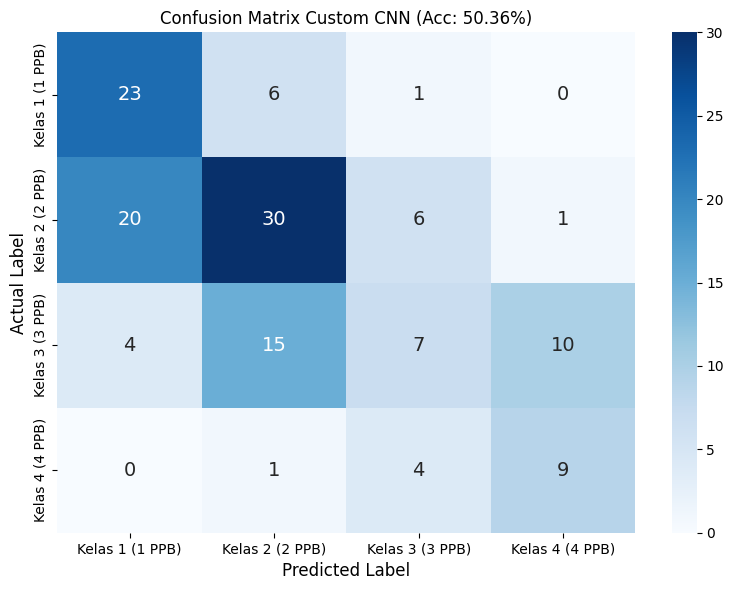

✅ Akurasi Global (Test): 50.36%
✅ Rata-rata Confidence: 51.98%


In [16]:
# =================================================================================================
# 6. EVALUASI AKHIR PADA DATA TEST
# =================================================================================================
print("\n[INFO] Melakukan Evaluasi pada Data Test...")

# Muat bobot model terbaik
try:
    model.load_weights(MODEL_SAVE_PATH)
    print(f"✓ Model terbaik berhasil dimuat dari {MODEL_SAVE_PATH}")
except:
    print("⚠️ Menggunakan bobot model epoch terakhir")

# Prediksi Probabilitas
Y_pred_probs = model.predict(test_ds, verbose=1)
y_pred = np.argmax(Y_pred_probs, axis=1) # Prediksi final

# Ambil Ground Truth (Karena 'categorical', bentuknya adalah One-Hot Vector, wajib di-argmax)
y_true_onehot = np.concatenate([y for x, y in test_ds], axis=0)
y_true = np.argmax(y_true_onehot, axis=1)

class_names = ['Kelas 1 (1 PPB)', 'Kelas 2 (2 PPB)', 'Kelas 3 (3 PPB)', 'Kelas 4 (4 PPB)']

# Hitung Akurasi & Confidence
test_acc = accuracy_score(y_true, y_pred)
confidence_scores = np.max(Y_pred_probs, axis=1)
avg_conf = np.mean(confidence_scores)

# Classification Report
report = classification_report(y_true, y_pred, target_names=class_names, digits=4, output_dict=True)
print("\n" + "=" * 60)
print("📋 CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_str = str(cm.tolist())

# Plot & Save Confusion Matrix
plot_folder = "history_plots_customCNN" 
if not os.path.exists(plot_folder):
    os.makedirs(plot_folder)

current_time_str = datetime.now().strftime("%Y%m%d_%H%M%S")
plot_filename = f"Custom_Acc{test_acc*100:.2f}_{current_time_str}.png"
plot_filepath = os.path.join(plot_folder, plot_filename)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 14})
plt.title(f'Confusion Matrix Custom CNN (Acc: {test_acc*100:.2f}%)')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()

plt.savefig(plot_filepath, dpi=300, bbox_inches='tight')
print(f"\n🖼️ Gambar Confusion Matrix tersimpan di: {plot_filepath}")
plt.show()

print(f"✅ Akurasi Global (Test): {test_acc*100:.2f}%")
print(f"✅ Rata-rata Confidence: {avg_conf*100:.2f}%")

✅ Visualisasi berhasil disimpan di: visualizations_CUSTOM\20260410_205837_Acc50.36.png


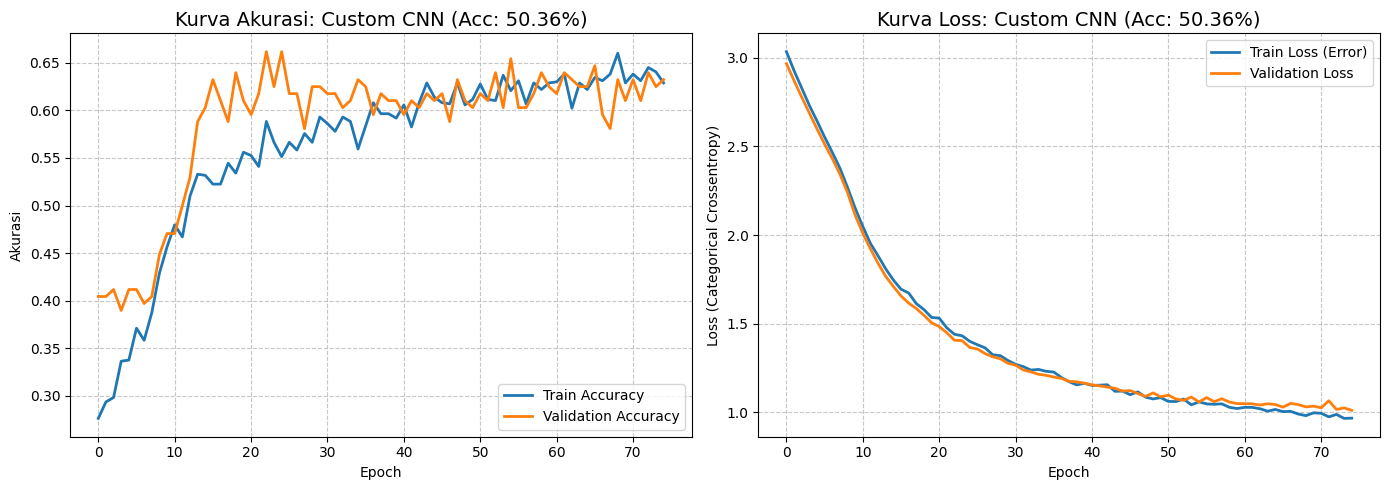

In [17]:
# =================================================================================================
# 7. VISUALISASI HASIL PELATIHAN
# =================================================================================================

plt.figure(figsize=(14, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title(f'Kurva Akurasi: Custom CNN (Acc: {test_acc*100:.2f}%)', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss (Error)', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title(f'Kurva Loss: Custom CNN (Acc: {test_acc*100:.2f}%)', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss (Categorical Crossentropy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

folder_name = "visualizations_CUSTOM"
if not os.path.exists(plot_folder):
    os.makedirs(plot_folder) # Buat folder otomatis jika belum ada
current_date = datetime.now().strftime("%Y%m%d_%H%M%S")
file_name = f"{current_date}_Acc{test_acc*100:.2f}.png"
save_path = os.path.join(folder_name, file_name)

plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ Visualisasi berhasil disimpan di: {save_path}")

# Menampilkan grafik di layar Jupyter
plt.show()

In [18]:
# =================================================================================================
# 8. SISTEM PENYIMPANAN LOG (AUTO-CSV)
# =================================================================================================
LOG_FILE_PATH = "experiment_log_custom_cnn.csv"

log_data = {
    "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "Model": "Custom CNN (Dual-Pooling UV)",
    "Total_Params": model.count_params(),
    "Learning_Rate": LEARNING_RATE,
    "Batch_Size": batch_size, # dari preprocess
    "Img_Size": img_height,   # dari preprocess
    "Use_Class_Weights": "Yes",
    "Accuracy": round(test_acc, 4),
    "Avg_Confidence": round(avg_conf, 4),
    "Confusion_Matrix": cm_str
}

# Ambil Precision/Recall/F1 tiap kelas
for idx, label in enumerate(class_names):
    # Menyiasati label name di report dictionary
    metrics = report[label] 
    log_data[f"C{idx+1}_Prec"] = round(metrics['precision'], 4)
    log_data[f"C{idx+1}_Rec"] = round(metrics['recall'], 4)
    log_data[f"C{idx+1}_F1"] = round(metrics['f1-score'], 4)

df_new_log = pd.DataFrame([log_data])

if not os.path.exists(LOG_FILE_PATH):
    df_new_log.to_csv(LOG_FILE_PATH, index=False)
    print(f"\n[SAVE] File log baru dibuat: {LOG_FILE_PATH}")
else:
    df_new_log.to_csv(LOG_FILE_PATH, mode='a', header=False, index=False)
    print(f"\n[SAVE] Hasil percobaan berhasil ditambahkan ke: {LOG_FILE_PATH}")

print("="*60)
print("EKSPERIMEN SELESAI!")
print("="*60)


[SAVE] Hasil percobaan berhasil ditambahkan ke: experiment_log_custom_cnn.csv
EKSPERIMEN SELESAI!
